 # Sales Data

In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stat


In [132]:
np.random.seed() # to set random seed for reproducibility

MIN_RANGE = 1
MAX_RANGE = 20
sale_start_date='2023-01-01'
categories =['Electronics', 'Clothing', 'Home', 'Sports']

data={
    'product_id': range(MIN_RANGE,1+MAX_RANGE),
    'product_name':[f'Product {i}' for i in range(MIN_RANGE,1+MAX_RANGE)],
    'category' : np.random.choice(categories, MAX_RANGE),
    'units_sold': np.random.poisson(lam=MAX_RANGE,size=MAX_RANGE),
    'sale_date':pd.date_range(start=sale_start_date,periods=MAX_RANGE,freq='D')

}

data
sales_df=pd.DataFrame(data)
sales_df.head(25)



,product_id,product_name,category,units_sold,sale_date
0,1,Product 1,Sports,19,2023-01-01
1,2,Product 2,Home,21,2023-01-02
2,3,Product 3,Sports,15,2023-01-03
3,4,Product 4,Sports,25,2023-01-04
4,5,Product 5,Electronics,22,2023-01-05
5,6,Product 6,Home,21,2023-01-06
6,7,Product 7,Sports,20,2023-01-07
7,8,Product 8,Home,22,2023-01-08
8,9,Product 9,Home,22,2023-01-09
9,10,Product 10,Home,18,2023-01-10


In [133]:

# Data set/File location
folder_name = '/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/assets/'
file_name = 'sales_file.csv'

file_location = folder_name+file_name 
print(file_location)
sales_df.to_csv(file_location,index=False)

/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/assets/sales_file.csv


# get current working directory

In [134]:
import os
os.getcwd() 

'/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/Statistics'

## Step 3: Descriptive Statistics

In [135]:
sales_df.columns

Index(['product_id', 'product_name', 'category', 'units_sold', 'sale_date'], dtype='object')

In [136]:
descriptive_stats = sales_df['units_sold'].describe()
print("Descriptive Statistics of Unts Sold")
print(descriptive_stats)


Descriptive Statistics of Unts Sold
count    20.0000
mean     19.2500
std       3.2424
min      13.0000
25%      17.0000
50%      19.0000
75%      22.0000
max      25.0000
Name: units_sold, dtype: float64


# Additional Statistics

In [137]:
attribute='units_sold'
mean_sales = sales_df[attribute].mean()
median_sales = sales_df[attribute].median()
mode_sales =sales_df[attribute].mode()[0]
variance_sales = sales_df[attribute].var()
sd_sales = sales_df[attribute].std()

print("Mean Sales = ",mean_sales)
print("Median Sales = ",median_sales)
print("Mode Sales = ",mode_sales)
print("Variance Sales = ",variance_sales)
print("Standard Deviation Sales = ",sd_sales)


Mean Sales =  19.25
Median Sales =  19.0
Mode Sales =  22
Variance Sales =  10.513157894736842
Standard Deviation Sales =  3.242400020777332


# Group by category and calculate  total and average slaes

In [138]:
category_stats = sales_df.groupby('category')['units_sold'].agg(['sum','mean','std']).reset_index()
category_stats.columns=['Category','Total Units Sold', 'Average Units Sold', 'Std Dev of Units Sold']
print("Category Statistics")
print(category_stats)

Category Statistics
      Category  Total Units Sold  Average Units Sold  Std Dev of Units Sold
0  Electronics                73              18.250               2.629956
1         Home               157              19.625               2.133910
2       Sports               155              19.375               4.501984


# Inferential Statistics

In [139]:
confidence_level = 0.95
degree_of_freedom = len(sales_df[attribute])-1
sample_mean = mean_sales
sample_standard_error = sd_sales / np.sqrt(len(sales_df[attribute]))

# t-score for confidence level

t_score = stat.t.ppf((1+confidence_level)/2, degree_of_freedom)
margin_of_error = t_score * sample_standard_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

print("\nConfidence Interval for the Mean of Units Sold:")
print(f"(min , max) : {confidence_interval[0]} , {confidence_interval[1]}")



Confidence Interval for the Mean of Units Sold:
(min , max) : 17.732510078899995 , 20.767489921100005


# Hypothesis Testing

In [140]:
# Hypothesis tesing : t-test
# null hypothesis : mean units sold is 20
# alternative hypothesis : mean units sold is not equal to 20

t_statistic,p_value = stat.ttest_1samp(sales_df[attribute],20)

print("\nHypothesis Testing (t-test):")
print(f"T-statistic: {t_statistic}, P-value: {p_value}")

if(p_value < 0.05):
  print("Reject the null hypothesis: The mean units sold is significantly different from 20.")
else:
    print("Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.")



Hypothesis Testing (t-test):
T-statistic: -1.0344503900680253, P-value: 0.3139134993958905
Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.


# Visualizations

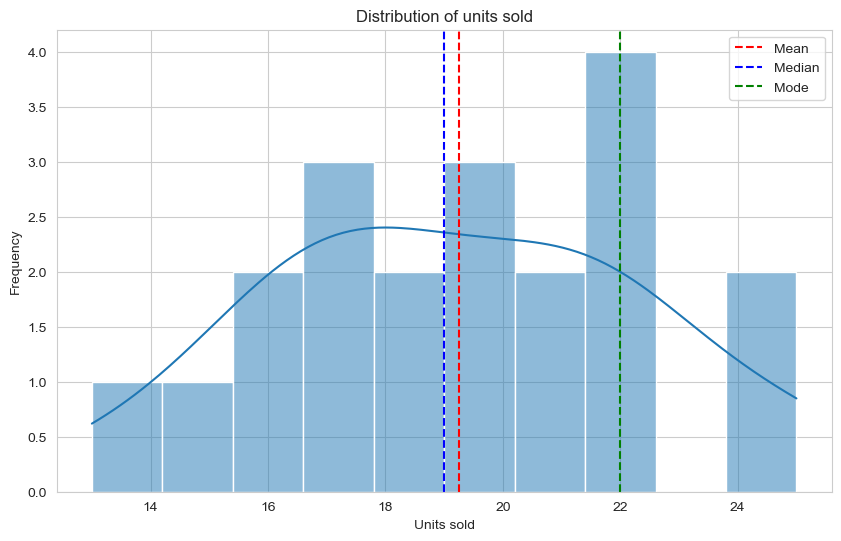

In [141]:
sns.set_style('whitegrid')

plt.figure(figsize=(10,6))
sns.histplot(sales_df[attribute],bins=10, kde=True)
plt.title("Distribution of units sold")
plt.xlabel('Units sold')
plt.ylabel("Frequency")
plt.axvline(mean_sales, color='red', linestyle ='--',label='Mean')
plt.axvline(median_sales,color = 'blue', linestyle ='--', label ='Median')
plt.axvline(mode_sales, color='green', linestyle='--', label ='Mode')
plt.legend()
plt.show()


/var/folders/d3/sygkv87x599_23wg1wtqq98c0000gp/T/ipykernel_20739/2230749763.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


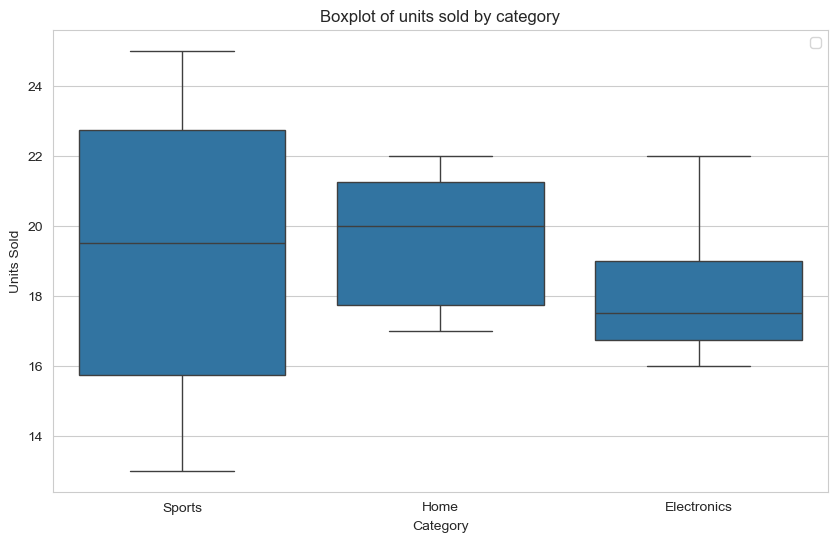

In [142]:

plt.figure(figsize=(10,6))
sns.boxplot(data=sales_df, x='category', y='units_sold')
plt.title("Boxplot of units sold by category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.legend()
plt.show()


Index(['product_id', 'product_name', 'category', 'units_sold', 'sale_date'], dtype='object')


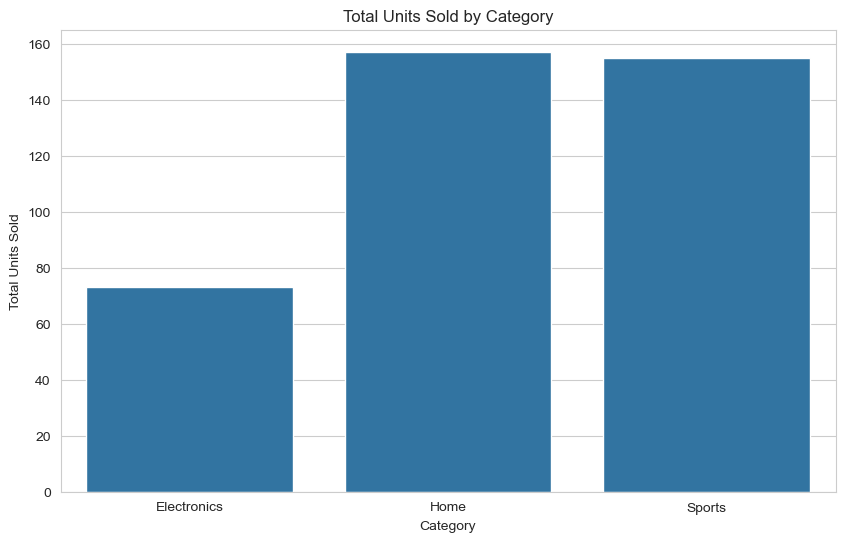

In [143]:
print(sales_df.columns)
# category_stats.columns=['Category','Total Units Sold'
plt.figure(figsize=(10,6))
sns.barplot(data=category_stats, x='Category', y ='Total Units Sold')

plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')

plt.show()